In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn as skl

In [20]:
dsj = pd.read_csv("./data_science_job.csv")
dsj.sample(10)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
12283,28687,city_75,0.939,Male,Has relevent experience,no_enrollment,Phd,STEM,8.0,1000-4999,Public Sector,302.0,0.0
15187,7525,city_159,0.843,Male,No relevent experience,Full time course,Graduate,STEM,4.0,NaN,NaN,56.0,0.0
10354,26952,city_16,0.910,Male,Has relevent experience,no_enrollment,Graduate,Humanities,5.0,500-999,Pvt Ltd,6.0,0.0
10972,16247,city_158,0.766,NaN,Has relevent experience,Part time course,High School,NaN,4.0,NaN,NaN,7.0,1.0
13715,33321,city_41,0.827,Female,Has relevent experience,no_enrollment,Graduate,Arts,11.0,5000-9999,Pvt Ltd,83.0,0.0
10397,13620,city_21,0.624,NaN,Has relevent experience,no_enrollment,Graduate,No Major,0.0,10/49,Pvt Ltd,146.0,0.0
5695,9735,city_104,NaN,Male,Has relevent experience,no_enrollment,Graduate,STEM,4.0,1000-4999,NaN,12.0,0.0
15484,16747,city_136,0.897,NaN,No relevent experience,Full time course,Masters,STEM,7.0,NaN,Pvt Ltd,30.0,0.0
4832,20100,city_160,0.920,Male,No relevent experience,Part time course,Graduate,STEM,4.0,10/49,Pvt Ltd,57.0,0.0
7758,27177,city_105,0.794,Male,Has relevent experience,no_enrollment,Masters,Business Degree,20.0,50-99,Funded Startup,30.0,0.0


In [21]:
dsj.isnull().mean() * 100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [22]:
nullCols = [col for col in dsj.columns if dsj[col].isnull().mean() < 0.05 and dsj[col].isnull().mean() > 0]
nullCols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [25]:
dsj[nullCols].sample(10)

,city_development_index,enrolled_university,education_level,experience,training_hours
1387,0.920,no_enrollment,Graduate,20.0,143.0
12674,0.624,no_enrollment,Masters,4.0,32.0
9970,0.920,no_enrollment,Graduate,3.0,74.0
14472,0.897,Part time course,Graduate,3.0,20.0
1707,0.624,Full time course,High School,2.0,3.0
6818,0.624,NaN,Masters,8.0,18.0
14324,0.920,no_enrollment,NaN,3.0,72.0
12529,0.899,no_enrollment,Graduate,20.0,57.0
16825,0.920,no_enrollment,Graduate,17.0,11.0
874,0.920,no_enrollment,Masters,4.0,127.0


In [26]:
len(dsj[nullCols].dropna()) / len(dsj)

0.8968577095730244

In [28]:
new_dsj = dsj[nullCols].dropna()
dsj.shape, new_dsj.shape

((19158, 13), (17182, 5))

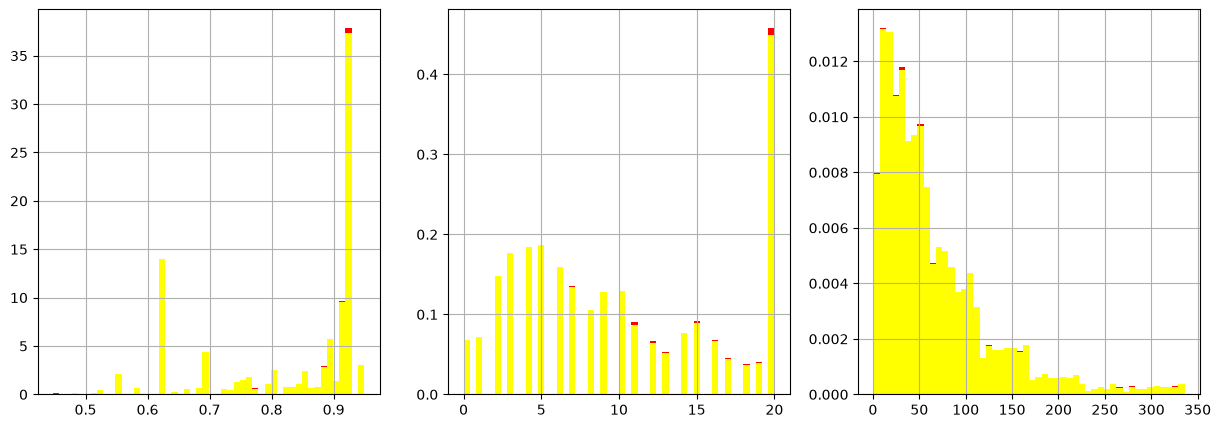

In [42]:

plt.subplot(131)
new_dsj[nullCols[0]].hist(bins= 50, density= True, figsize= (15, 5), color= "red")
dsj[nullCols[0]].hist(bins= 50, density= True, figsize= (15, 5), color= "yellow")

plt.subplot(132)
new_dsj[nullCols[3]].hist(bins= 50, density= True, figsize= (15, 5), color= "red")
dsj[nullCols[3]].hist(bins= 50, density= True, figsize= (15, 5), color= "yellow")

plt.subplot(133)
new_dsj[nullCols[4]].hist(bins= 50, density= True, figsize= (15, 5), color= "red")
dsj[nullCols[4]].hist(bins= 50, density= True, figsize= (15, 5), color= "yellow")
# plt.tight_layout()
plt.show()

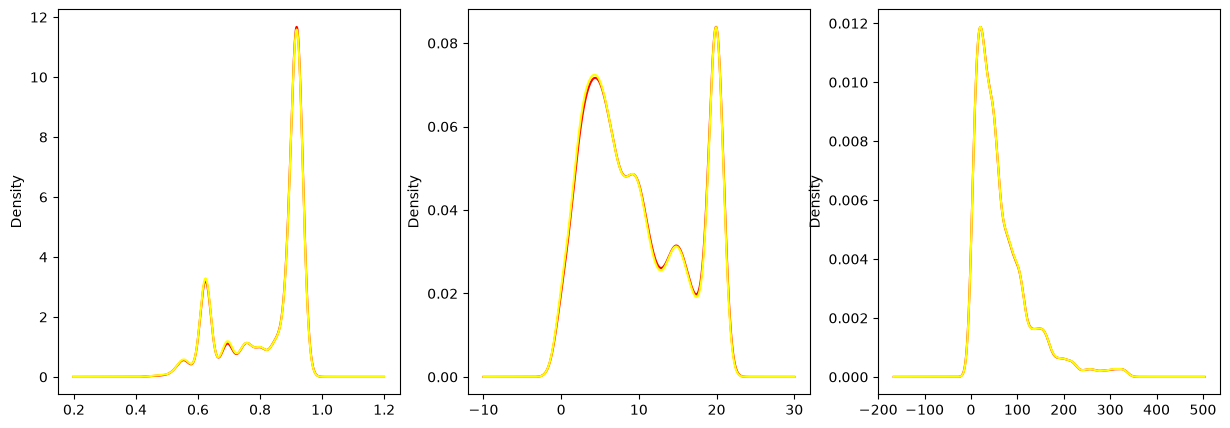

In [ ]:

plt.subplot(131)
new_dsj[nullCols[0]].plot.density(figsize= (15, 5), color= "red")
dsj[nullCols[0]].plot.density(figsize= (15, 5), color= "yellow")

plt.subplot(132)
new_dsj[nullCols[3]].plot.density(figsize= (15, 5), color= "red")
dsj[nullCols[3]].plot.density(figsize= (15, 5), color= "yellow")

plt.subplot(133)
new_dsj[nullCols[4]].plot.density(figsize= (15, 5), color= "red")
dsj[nullCols[4]].plot.density(figsize= (15, 5), color= "yellow")
# plt.tight_layout()
plt.show()

In [48]:
temp_eu = pd.concat([
    dsj["enrolled_university"].value_counts() / len(dsj),
    new_dsj["enrolled_university"].value_counts() / len(dsj)
    ], axis= 1)
temp_eu.columns = ["original", "CCA"]

temp_eu

,original,CCA
enrolled_university,,
no_enrollment,0.721213,0.659359
Full time course,0.196106,0.180029
Part time course,0.062533,0.057469


In [50]:
temp_el = pd.concat([
    dsj["education_level"].value_counts() / len(dsj),
    new_dsj["education_level"].value_counts() / len(dsj)
    ], axis= 1)
temp_el.columns = ["original", "CCA"]

temp_el["original"].mean(), temp_el["CCA"].mean()


(np.float64(0.19519782858335943), np.float64(0.17937154191460486))